---
title: Collecting and Manipulating AORC Data  
authors:  
  - name: Tony Castronova  
    email: acastronova@cuahsi.org  
  - name: Irene Garousi-Nejad  
    email: igarousi@cuahsi.org  
affiliations: 
  - id: CUAHSI
    name: CUAHSI
    url: https://www.CUAHSI.org 
date: 2026-04-10  
subject: Code Labs  
venue:  
  title: View Resource on HydroShare  
  url: https://hydroshare.org/resource/1977d240d66b42b69a46e3bcd896d7df/  
github: https://github.com/CUAHSI/notebooks/blob/develop/Data%20Access%20Examples/AORC%20-%20Data%20Collection%20and%20Manipulation%20Primer/collecting-and-manipulating-aorc-v1.1.ipynb  
downloads:  
    - file: collecting-and-manipulating-aorc-v1.1.pdf  
---

**Description**:  

This notebooks explores methods for working with large cloud data stores using tools such as `xarray`, `dask`, and `geopandas`. This exploration is uses the Analysis of Record for Collaboration (AORC) v1.1 meteorological dataset that is used by the NOAA National Water Model. This notebook provides examples for how to access, slice, and visualize a large cloud-hosted dataset as well as an approach for aligning these data with watershed vector boundaries.

The data used in this notebook can be found at https://registry.opendata.aws/nwm-archive/.


**Software Requirements**:  

The software and operating system versions used to develop this notebook are listed below. To avoid encountering issues related to version conflicts among Python packages, we recommend creating a new environment variable and installing the required packages specifically for this notebook.

> fsspec    >= 2024.6.0  
geopandas >= 0.14.4  
numpy     >= 1.26.4  
matplotlib >= 3.9.0  
sys       >= 3.12.3   
dask      >= 2024.5.2  
xarray    >= 2024.5.0  
rioxarray >= 0.15.5  
geocube   >= 0.5.2  
s3fs      >= 2024.6.0  
zarr      >= 2.18.2  
jupyterlab >= 4.4.3  
dask_labextension >= 7.0.0  (optional)
---

In [2]:
import sys
import dask
import numpy
import xarray as xr
import fsspec
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from dask.distributed import Client
from geocube.api.core import make_geocube

import warnings
warnings.filterwarnings("ignore")

We'll use `dask` to parallelize our code. This is a very powerful library that has been integrated into libraries such as `xarray` which enables us to use its capabilities without writing any parallel code. However, the process for writing parallel code using `dask` is straightforward and well documented, for more information see their website [here](https://www.dask.org/). [The 10 minutes to Dask](https://docs.dask.org/en/stable/10-minutes-to-dask.html) overview is a good place to start for new users.

In this notebook, we'll be using `dask` to speed up our access of the AORC dataset. To visualize the progress of long running jobs, we'll first need to create a "cluster." The cluster defines the number of workers and their respective computing resources. This should be scaled to the hardware that you have access to.

In [3]:
# use a try accept loop so we only instantiate the client
# if it doesn't already exist.
try:
    print(client.dashboard_link)
except:    
    # The client should be customized to your workstation resources.
    # This is configured for a "Large" instance on ciroh.awi.2i2c.cloud
    # client = Client()
    client = Client(n_workers=8, memory_limit='10GB') # Large Machine
    print(client.dashboard_link)

http://127.0.0.1:62721/status


---

## Access the AORC Forcing Data using Xarray

In this notebook we'll be working with AORC v1.1 meteorological forcing. These 1km hourly gridded datasets are publicly available as part of the NOAA National Water Model v3.0 Retrospective archive on AWS registry of open data. These data are available in the `Zarr` format which offers a convienent and efficient means for slicing and subsetting very large datasets using libraries such as `xarray`. The following link will navigate you to the data, this can be helpful for understanding what data are available and how they are structured:

Homepage  : https://registry.opendata.aws/nwm-archive/  
Zarr Store: https://noaa-nwm-retrospective-3-0-pds.s3.amazonaws.com/index.html#CONUS/zarr/ 

---

**Note: (https://registry.opendata.aws/nwm-archive/)**
> Versions 3.0 and 2.1: NWM Retrospective simulations used forcing from the Office of Water Prediction Analysis of Record for Calibration (AORC) dataset. NWM v2.1 used AORC v1.0 for 1979-2006 and AORC v1.1 for 2007-2020, while NWM v3.0 used AORC v1.1 for the full v3.0 (1979-2023 period)


Define a few parameters for accessing the specific variable that we're interested in.

In [4]:
bucket_url = 's3://noaa-nwm-retrospective-3-0-pds'
region = 'CONUS'
variable = 'precip'

We'll use the `fsspec` library to load these data. The `fsspec` library provides a filesystem interface for data accessing remote data such as the AORC Zarr store on AWS. To learn more about `fsspec`, see their documentation [here](https://filesystem-spec.readthedocs.io/en/latest/). Since these data are stored in an S3 bucket, `fsspec` will leverage the `s3fs` package to provide a filesystem interface to S3.

In [5]:
# build a path to the zarr store that we want
s3path = f"{bucket_url}/{region}/zarr/forcing/{variable}.zarr"

# load these data using xarray
ds = xr.open_zarr(fsspec.get_mapper(s3path, anon=True), consolidated=True)

ds

<xarray.Dataset> Size: 27TB
Dimensions:   (time: 385704, y: 3840, x: 4608)
Coordinates:
  * time      (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x         (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y         (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
Data variables:
    RAINRATE  (time, y, x) float32 27TB dask.array<chunksize=(672, 350, 350), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

Notice that this loaded very fast. That's because it performed a "lazy" load of the data, i.e. only the metadata was loaded. Data values will not be accessed until computations are performed.

In [6]:
print(f'Total Size of AORC: {ds.nbytes/1e12:.1f} TB')
print(f'Size Loaded into Memory: {sys.getsizeof(ds)} bytes')

Total Size of AORC: 27.3 TB
Size Loaded into Memory: 112 bytes


## Slicing and Visualizing the AORC Data

Since this is a lot of data, let's reduce the size that we're looking at to a single timestep. We can do this in a number of ways, however in this case we're just selecting the first index of data. For more information on slicing data, see the xarray documentation [here](https://docs.xarray.dev/en/v2023.09.0/user-guide/indexing.html).

#### Slice these Data using Xarray Indexing

In [7]:
# Slice data using index locators
ds_sel = ds.isel(time=0)
ds_sel

<xarray.Dataset> Size: 71MB
Dimensions:   (y: 3840, x: 4608)
Coordinates:
    time      datetime64[ns] 8B 1979-02-01
  * x         (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y         (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
Data variables:
    RAINRATE  (y, x) float32 71MB dask.array<chunksize=(350, 350), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

In [8]:
# select using multiple locators
ds_sel = ds.isel(time=0, x=1000, y=1000)
ds_sel

<xarray.Dataset> Size: 29B
Dimensions:   ()
Coordinates:
    time      datetime64[ns] 8B 1979-02-01
    x         float64 8B -1.303e+06
    y         float64 8B -9.195e+05
Data variables:
    RAINRATE  float32 4B dask.array<chunksize=(), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

In [9]:
# Query the RAINRATE value associated with this slice of the AORC 
ds_sel.RAINRATE.values

array(0., dtype=float32)

Selecting a specific data point in time is not very useful. Often we're interested in a time series of data. Let's extend our previous example to collect data through a range of time. This can be done using indexing as before:

In [10]:
ds_sel = ds.isel(time=range(0, 100), # use range to select multiple indices
                 x=1000,
                 y=1000)
ds_sel

<xarray.Dataset> Size: 1kB
Dimensions:   (time: 100)
Coordinates:
  * time      (time) datetime64[ns] 800B 1979-02-01 ... 1979-02-05T03:00:00
    x         float64 8B -1.303e+06
    y         float64 8B -9.195e+05
Data variables:
    RAINRATE  (time) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

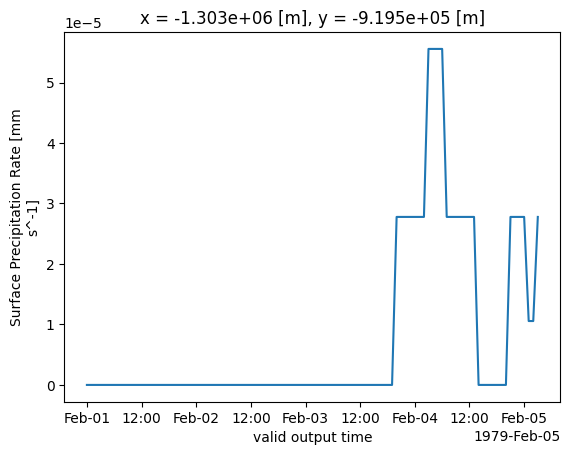

In [11]:
# Plot the timeseries of data associated with the RAINRATE variable
ds_sel.RAINRATE.plot();

We now have a timeseries at a single grid cell, but we defined the time range using array indexing. This makes it difficult to select a specific time range of interest. We can use datetime slicing instead of array indexing to acquire a more precise time range. First let's figure out the data range for which data is available by returning the minimum and maximum dates in the dataset.

In [12]:
dt_min = ds.time.min().values
dt_max = ds.time.max().values
print(f'The daterange of our data is {dt_min} - {dt_max}')

The daterange of our data is 1979-02-01T00:00:00.000000000 - 2023-01-31T23:00:00.000000000


Next we can slice our data for a time span within this range.

In [13]:
# select the spatial area of interest using array indexing
ds_sel = ds.isel(x=1000,
                 y=1000)

# select the time span of interest using date range slicing
ds_sel = ds_sel.sel(time=slice('2020-01-01', '2021-01-01'))

ds_sel

<xarray.Dataset> Size: 106kB
Dimensions:   (time: 8808)
Coordinates:
  * time      (time) datetime64[ns] 70kB 2020-01-01 ... 2021-01-01T23:00:00
    x         float64 8B -1.303e+06
    y         float64 8B -9.195e+05
Data variables:
    RAINRATE  (time) float32 35kB dask.array<chunksize=(192,), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

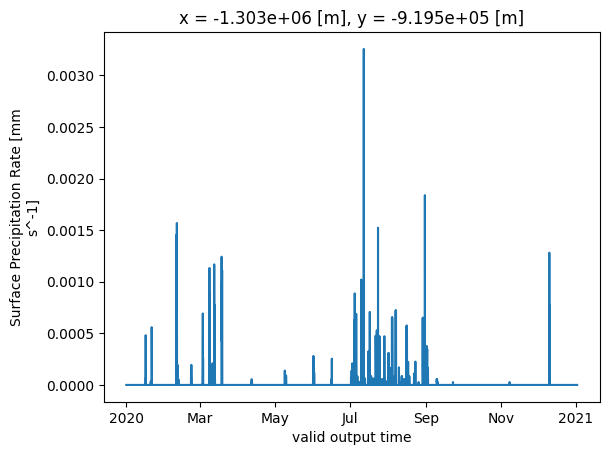

In [14]:
# Plot the timeseries of data associated with the RAINRATE variable.
ds_sel.RAINRATE.plot();

Similarly we can modify our example to select a spatial range rather than a single grid cell. This can easily be done using array indexing:

In [15]:
# select the spatial area of interest using array indexing
ds_sel = ds.isel(x=range(1000, 2000),
                 y=range(1000,2000))

# select the time span of interest using date range slicing
ds_sel = ds_sel.sel(time=slice('2020-01-01', '2021-01-01'))

ds_sel

<xarray.Dataset> Size: 35GB
Dimensions:   (time: 8808, y: 1000, x: 1000)
Coordinates:
  * time      (time) datetime64[ns] 70kB 2020-01-01 ... 2021-01-01T23:00:00
  * x         (x) float64 8kB -1.303e+06 -1.302e+06 ... -3.055e+05 -3.045e+05
  * y         (y) float64 8kB -9.195e+05 -9.185e+05 ... 7.85e+04 7.95e+04
Data variables:
    RAINRATE  (time, y, x) float32 35GB dask.array<chunksize=(192, 349, 329), meta=np.ndarray>
    crs       |S1 1B ...
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

We now have 1000x1000 arrays of data stacked through time. Plotting becomes a bit more tricky here, but we can preview our data by plotting at a single time step.

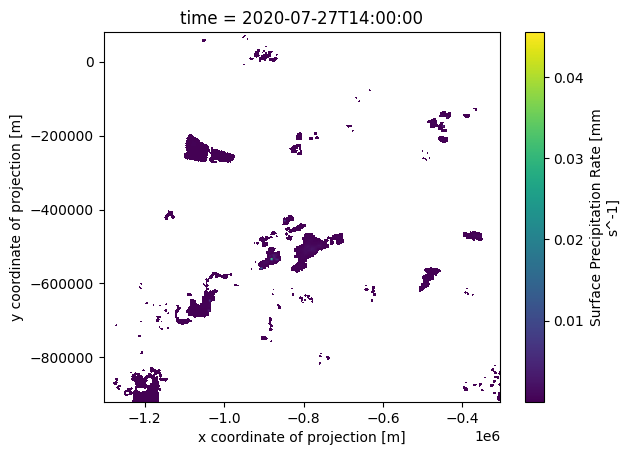

In [16]:
# select a single time within our data cube
rainrate = ds_sel.isel(time=5006).RAINRATE

# plot the values where rainrate is greater than 0.0
rainrate.where(rainrate > 0.0).plot();

We can extend this example to select a spatial using coordinate values instead of array indices.

In [17]:
ymin = -846500.312
ymax = -786500.312
xmin = -1274499.125
xmax = -426499.1875

# select the time span and spatial area of interest using slicing
ds_sel = ds_sel.sel(time=slice('2020-01-01', '2021-01-01'),
                    y=slice(ymin, ymax),
                    x=slice(xmin, xmax))

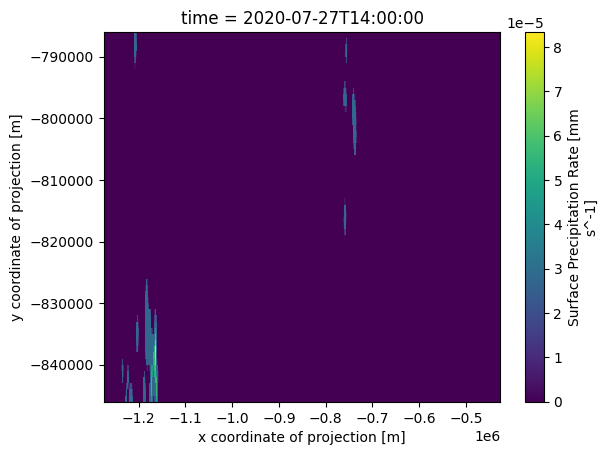

In [18]:
# plot  a single time step within our data cube
ds_sel.isel(time=5006).RAINRATE.plot();

## Aligning Gridded AORC with Watershed Vectors

Often times we are interested in gridded data that aligns with a vector area such as a watershed boundary. We can align the AORC gridded data on vectors using the geocube library. First, let's load a watershed Shapefile that defines our area of interest. `GeoPandas` makes working with Shapefiles in Python very easy and intuitive:

<Axes: >

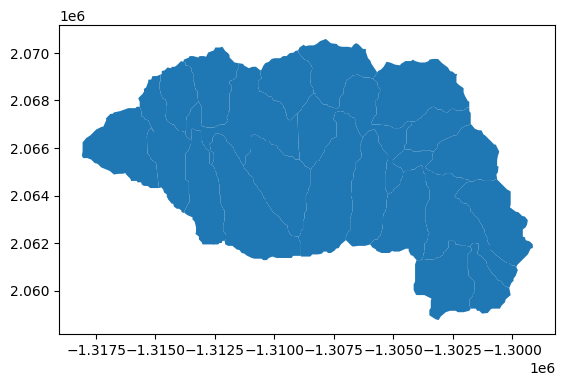

In [19]:
# load the watershed shapefile
gdf = gpd.read_file('sample-data/watershed.shp')

# preview the watershed
gdf.plot()

We can also preview the attributes of this shapefile.

In [20]:
gdf

,id,divide_id,toid,type,ds_id,areasqkm,lengthkm,tot_draina,has_flowli,geometry
0,cat-2853632,cat-2853632,nex-2853609,network,None,6.082650,3.584774,6.082650,1,"POLYGON ((-1299825 2060985, -1299885 2061045, ..."
1,cat-2853609,cat-2853609,nex-2853610,network,None,8.535150,7.316047,33.874199,1,"POLYGON ((-1300485 2060415, -1300575 2060415, ..."
2,cat-2853634,cat-2853634,nex-2853633,network,None,5.524650,1.968327,5.524650,1,"POLYGON ((-1303455 2058945, -1303485 2058975, ..."
3,cat-2853633,cat-2853633,nex-2853610,network,None,2.854800,2.403763,2.854800,1,"POLYGON ((-1301775 2061855, -1301655 2062005, ..."
4,cat-2853630,cat-2853630,nex-2853610,network,None,5.948099,3.712462,5.948099,1,"POLYGON ((-1304175 2061465, -1304265 2061495, ..."
5,cat-2853631,cat-2853631,nex-2853610,network,None,4.928850,2.878838,4.928850,1,"POLYGON ((-1302075 2064705, -1302135 2064765, ..."
6,cat-2853629,cat-2853629,nex-2853610,network,None,3.303900,2.938029,3.303900,1,"POLYGON ((-1304535 2065965, -1304535 2066115, ..."
7,cat-2853610,cat-2853610,nex-2853611,network,None,8.628300,5.343603,74.593799,1,"POLYGON ((-1305645 2066985, -1305405 2067015, ..."
8,cat-2853627,cat-2853627,nex-2853611,network,None,8.110350,4.202267,8.110350,1,"POLYGON ((-1305945 2067015, -1305795 2067345, ..."
9,cat-2853628,cat-2853628,nex-2853611,network,None,5.928751,5.203622,5.928750,1,"POLYGON ((-1306995 2062125, -1306995 2062275, ..."


To align the gridded AORC data on these vector boundaries we need to first set the coordinate reference system (CRS) within the xarray dataset. It's CRS is defined in the metadata but it isn't set in a way that we can leverage it. Let's change that by using the rasterIO extension to xarray, called `rioxarray`. 

In [21]:
# set the crs in the dataset
ds.rio.set_crs(ds.crs.attrs['esri_pe_string'])
ds.rio.write_crs(inplace=True)

<xarray.Dataset> Size: 27TB
Dimensions:   (time: 385704, y: 3840, x: 4608)
Coordinates:
    crs       int64 8B 0
  * time      (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x         (x) float64 37kB -2.303e+06 -2.302e+06 ... 2.303e+06 2.304e+06
  * y         (y) float64 31kB -1.92e+06 -1.919e+06 ... 1.918e+06 1.919e+06
Data variables:
    RAINRATE  (time, y, x) float32 27TB dask.array<chunksize=(672, 350, 350), meta=np.ndarray>
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

Next we need to make sure that the AORC CRS matches that of our watershed. If these don't align, we'll need to perform geospatial transformations before moving on.

In [22]:
print(f'AORC CRS:\n-----\n{ds.rio.crs.to_proj4()}')
print(f'\nShapefile CRS:\n-----\n{gdf.crs.to_proj4()}')

AORC CRS:
-----
+proj=lcc +lat_0=40 +lon_0=-97 +lat_1=30 +lat_2=60 +x_0=0 +y_0=0 +R=6370000 +units=m +no_defs=True

Shapefile CRS:
-----
+proj=aea +lat_0=23 +lon_0=-96 +lat_1=29.5 +lat_2=45.5 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs +type=crs


Since these coordinate systems differ, we'll need to convert one of them so that they align.

In [23]:
# convert the shapefile into the coordinate system of the xarray dataset
gdf = gdf.to_crs(ds.rio.crs)
print(f'\nShapefile CRS:\n-----\n{gdf.crs.to_proj4()}')


Shapefile CRS:
-----
+proj=lcc +lat_0=40 +lon_0=-97 +lat_1=30 +lat_2=60 +x_0=0 +y_0=0 +R=6370000 +units=m +no_defs +type=crs


Let's clip the AORC data to the extent of this watershed. This can be done using `rioxarray`'s "clip" method.

In [24]:
# clip the data
ds_sel = ds.rio.clip(
         gdf.geometry.values,
         gdf.crs,
         all_touched=True,   # select all grid cells that touch the vector boundary
         drop=True,          # drop anything that is outside the clipped region
         invert=False,
         from_disk=True)
ds_sel

<xarray.Dataset> Size: 384MB
Dimensions:      (time: 385704, x: 19, y: 13)
Coordinates:
  * time         (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x            (x) float64 152B -1.202e+06 -1.201e+06 ... -1.184e+06
  * y            (y) float64 104B 1.705e+05 1.715e+05 ... 1.815e+05 1.825e+05
    spatial_ref  int64 8B 0
    crs          int64 8B 0
Data variables:
    RAINRATE     (time, y, x) float32 381MB dask.array<chunksize=(672, 10, 19), meta=np.ndarray>
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

Preview our data at a single point in time. We'll use some `matplotlib` features to make a more interesting plot that contains both our gridded data as well as our vector data.

<Axes: title={'center': 'time = 1979-08-28T14:00:00, spatial_ref = 0, cr...'}, xlabel='x coordinate of projection\n[metre]', ylabel='y coordinate of projection\n[metre]'>

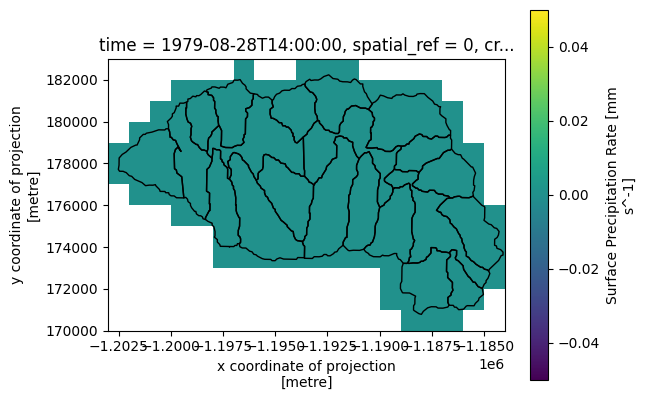

In [25]:
fig, ax = plt.subplots()

# add RAINRATE at a single time to the plot
ds_sel.isel(time=5006).RAINRATE.plot(ax=ax)

# add our watershed to the plot
gdf.plot(ax=ax, facecolor='none', edgecolor='k')

We've clipped the AORC dataset to the extent of our watershed boundary, however it still has no relation to the individual subcatchments. To better connect these two datasets, we can create a new dataset variable that represents a mask of grid cells that are associated with each subcatchment. We'll use the `geocube` library to accomplish this task.

Note that the method we're using will associate grid cell with the watershed that it overlaps the most with. There are more advanced ways to create a mapping using various interpolation methods that will distribute values cells across all watershed boundaries that they intersect with. This is left as a future exercise.

In [26]:
# create zonal id column
gdf['cat'] = gdf.id.str.split('-').str[-1].astype(int)

# select a single array of data to use as a template
rainrate_data = ds_sel.isel(time=0).RAINRATE

# create a grid for the geocube
out_grid = make_geocube(
    vector_data=gdf,
    measurements=["cat"],
    like=ds_sel # ensure the data are on the same grid
)

# add the catchment variable to the original dataset
ds_sel = ds_sel.assign_coords(cat = (['y','x'], out_grid.cat.data))

# compute the unique catchment IDs which will be used to compute zonal statistics
catchment_ids = numpy.unique(ds_sel.cat.data[~numpy.isnan(ds_sel.cat.data)])

print(f'The dataset contains {len(catchment_ids)} catchments')
ds_sel

The dataset contains 21 catchments


<xarray.Dataset> Size: 384MB
Dimensions:      (time: 385704, x: 19, y: 13)
Coordinates:
  * time         (time) datetime64[ns] 3MB 1979-02-01 ... 2023-01-31T23:00:00
  * x            (x) float64 152B -1.202e+06 -1.201e+06 ... -1.184e+06
  * y            (y) float64 104B 1.705e+05 1.715e+05 ... 1.815e+05 1.825e+05
    spatial_ref  int64 8B 0
    crs          int64 8B 0
    cat          (y, x) float64 2kB nan nan nan nan nan ... nan nan nan nan nan
Data variables:
    RAINRATE     (time, y, x) float32 381MB dask.array<chunksize=(672, 10, 19), meta=np.ndarray>
Attributes:
    NWM_version_number:   v2.1
    model_configuration:  AORC
    model_output_type:    forcing

We can now select and plot data for spatial areas that correspond with out catchment identifiers.

(170499.65625, 182499.65625)

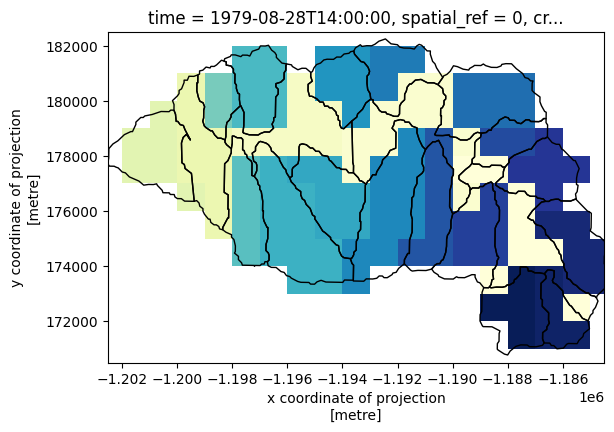

In [32]:
fig, ax = plt.subplots()

# plot RAINRATE for a single catchment
ds_sel.isel(time=5006).cat.plot(ax=ax, levels=35, cmap='tab20b',add_colorbar=False);

# add our watershed to the plot
gdf.plot(ax=ax, facecolor='none', edgecolor='k');

# adjust the x and y limits of the plot so we can see the entire watershed.
ax.set_xlim(ds_sel.x.min(), ds_sel.x.max())
ax.set_ylim(ds_sel.y.min(), ds_sel.y.max())

We can plot data for a single catchment by filtering on it's catchment identifier. These identifers are defined by the geopandas dataframe:

In [ ]:
gdf.cat.unique()

array([2853632, 2853609, 2853634, 2853633, 2853630, 2853631, 2853629,
       2853610, 2853627, 2853628, 2853626, 2853625, 2853611, 2853622,
       2853624, 2853623, 2853620, 2853621, 2853619, 2853612, 2853613])

(170499.65625, 182499.65625)

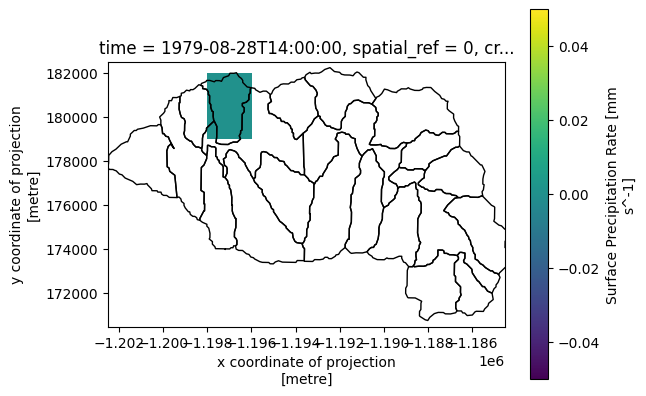

In [ ]:
fig, ax = plt.subplots()

# plot RAINRATE for a single catchment
cat_id=2853621
ds_sel.isel(time=5006).where(ds_sel.cat==cat_id, drop=True).RAINRATE.plot(ax=ax);

# add our watershed to the plot
gdf.plot(ax=ax, facecolor='none', edgecolor='k');

# adjust the x and y limits of the plot so we can see the entire watershed.
ax.set_xlim(ds_sel.x.min(), ds_sel.x.max())
ax.set_ylim(ds_sel.y.min(), ds_sel.y.max())

We can now perform computations on AORC data that aligns with subcatchments. For example, let's plot the average precipitation rate for a single catchment through time.

In [ ]:
# perform spatial selection using the catchment id defined in the cell above.
dat = ds_sel.where(ds_sel.cat==cat_id, drop=True)

# compute mean rainrate across dimensions x and y.
dat = dat.RAINRATE.mean(dim=['x','y'])

# slice our dataset to a reasonable time range
dat = dat.sel(time=slice('2020-01-01', '2020-06-01')).compute()  # triggers the computation

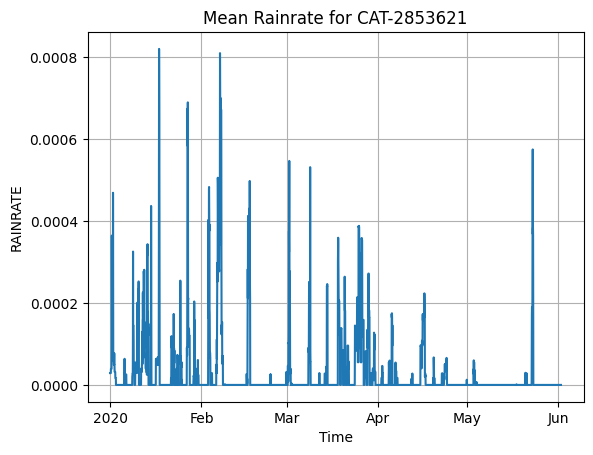

In [ ]:
fig, ax = plt.subplots()

dat.plot(ax=ax)
ax.set_title(f'Mean Rainrate for CAT-{cat_id}')
ax.set_xlabel('Time')
plt.grid()